# 8. Embedding 

## 0. Environment Setting

In [8]:
# scikit learn install
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [1]:
%pip install langchain langchain_community sentence-transformers scikit-learn matplotlib

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/571.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/571.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/571.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/571.3 kB ? eta -:--:--
   ------------------ --------------------- 262.1/571.3 kB ? eta -:--:--
   ------------------ --------------------- 262.1/571.3 kB ? eta -:--:--
   ------------------ --------------------

# 1. What are Embeddings? - GPS cordinates of meaning

### The Analogy 
imagine every word or sentence has a GPS location on a giant map of meaning

- "king" might be at (0.8, 0.9) because it has strong associations with royalty and power
- "queen" might be at (0.8, 0.85) because it's similar to "king" but slightly different
- "apple" might be at (0.2, 0.3) because it's associated with fruit and food 


## Technical Definition
An embedding is a list of numberes (typicall 384 to 3072 ) that represent the meaning of a word, sentence, or document in a high-dimensional space.


In [9]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')
sentences = ['This is an example sentence', 'Each sentence is converted']
embeddings = model.encode(sentences)

# let see what print
print(f"Sentences:{sentences}")
# print(f"Embeddings: {embeddings}")
print(f"Embedding type: {type(embeddings)}")
print(f"Number of dimensions: {len(embeddings)}")

# let's see the first embedding 
print(f"\nFirst 10 embedding values: {embeddings[0][:10]}")




Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4936.96it/s]


Sentences:['This is an example sentence', 'Each sentence is converted']
Embedding type: <class 'numpy.ndarray'>
Number of dimensions: 2

First 10 embedding values: [ 0.0676569   0.06349594  0.04871307  0.07930494  0.03744803  0.00265279
  0.03937497 -0.00709845  0.05936146  0.03153701]


In [3]:
# let embedding multiple sentences at once and compare their shape 
sentences = [
    "I love natural language processing.",
    "The cat is on the roof.",
    "This is a test sentence for embedding."
]

embeddings = model.encode(sentences)

print(f"Shape of embeddings: {embeddings.shape}")

print(f" -> {embeddings.shape[0]} sentences, each with {embeddings.shape[1]} dimensions")

for i, sentence in enumerate(sentences):
    print(f"\nSentence: '{sentence}'")
    print(f"Embedding (first 10 values): {embeddings[i][:10]}")

    


Shape of embeddings: (3, 384)
 -> 3 sentences, each with 384 dimensions

Sentence: 'I love natural language processing.'
Embedding (first 10 values): [ 3.9209306e-02 -7.8316770e-02  5.5135764e-02  3.7843445e-05
  3.5784252e-02 -5.4704420e-02  1.7946335e-02 -3.7338291e-04
  8.1795521e-02  4.3109454e-02]

Sentence: 'The cat is on the roof.'
Embedding (first 10 values): [ 0.09014214  0.07564275  0.02024744  0.01272278 -0.04801316 -0.01238957
  0.01491045  0.02082066 -0.00077051  0.02547914]

Sentence: 'This is a test sentence for embedding.'
Embedding (first 10 values): [ 0.02782416  0.00170263  0.08005545  0.04666286  0.03852202  0.05190131
  0.00691988 -0.05277489  0.01878231 -0.026011  ]


## 2.  why embeddings enable search 


In [13]:
# lets prove that embeddings understand meaning not keyworkds

from sklearn.metrics.pairwise import cosine_similarity 
sentences = [
    "I love natural language processing.",
    "The  natual language is very interesting.",
    "This is a test sentence for embedding."
]

embeddings = model.encode(sentences)

similarity_matrix = cosine_similarity(embeddings)

print(f"Semantic search proof")

print("=" * 50)

print(f"\ncosine similarity between sentence 1 and 2: {similarity_matrix[0][1]:.4f}")
print(f"cosine similarity between sentence 1 and 3: {similarity_matrix[0][2]:.4f}")
print(f"\ncosine similarity between sentence 2 and 3: {similarity_matrix[1][2]:.4f}")
print(f"cosine similarity between sentence 1 and itself: {similarity_matrix[0][0]:.4f}")

Semantic search proof

cosine similarity between sentence 1 and 2: 0.4760
cosine similarity between sentence 1 and 3: 0.2945

cosine similarity between sentence 2 and 3: 0.1587
cosine similarity between sentence 1 and itself: 1.0000


# 3. Dense Vector  ------ The Semantic Champions
The embeddings we just created are caled Dense Vectors because 
every number has a value --- none are zero.


- Dimensionality: The number of numbers in the vector (e.g., 384, 768, 1024, 3072)
- Dense: Every number has a value (no zeros)
- Semantic: They capture the meaning of the text, not just the words
- Created : Neural Networks trained on massive text data
- Used for: Search, Clustering, Classification, and more
- Example: "king" might be represented as [0.8, 0.9, 0.1, ...] and "queen" as [0.8, 0.85, 0.1, ...] showing their similarity in meaning

- `if values are close to zero then the word is not good`

- `if values are close to 1 then the word is good` 

In [6]:
import numpy as np

samples_embedding = model.encode("This is a sample sentence for visualization.")

# count how many values are non zero 
# np.count_nonzero(samples_embedding)
non_zero_values = np.count_nonzero(samples_embedding)
total_dimensions = len(samples_embedding)
zero_count = total_dimensions - non_zero_values

print(f"Total dimensions: {total_dimensions}")
print(f"Non-zero values: {non_zero_values}")
print(f"Zero values: {zero_count}")
print(f"Density of embedding: {non_zero_values/total_dimensions:.4f}")




Total dimensions: 384
Non-zero values: 384
Zero values: 0
Density of embedding: 1.0000


# 4 . Sparse Vector  ------ The Keyword Experts
- Sparse Vectors are the opposite of Dense Vectors. 
- They have many zeros and only a few non-zero values. 
- They are often used in traditional keyword-based search systems.
- `Dense wins for meaning, Sparse wins for keywords`

-`The best system combine both that is called **Hybrid Search**`


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

sentences = [
    "The parrots are flying in the sky.",
    "The birds are flying in the sky.",
    "The cat is on the roof."
]

vectorizer = TfidfVectorizer()
sparse_embeddings = vectorizer.fit_transform(sentences)

vocabulary = vectorizer.get_feature_names_out()

print(f"Vocabulary: {vocabulary}")
print(f"\nVocabulary size: {len(vocabulary)}")
print(f"List of Vocabulary: {list (vocabulary)}")
print(f"\nShape of sparse embeddings: {sparse_embeddings.shape}")


# convert sparse matrix to dense and print the first embedding
dense_embeddings = sparse_embeddings.toarray()[0]
print(f"\nFirst embedding: {dense_embeddings}")





Vocabulary: ['are' 'birds' 'cat' 'flying' 'in' 'is' 'on' 'parrots' 'roof' 'sky' 'the']

Vocabulary size: 11
List of Vocabulary: ['are', 'birds', 'cat', 'flying', 'in', 'is', 'on', 'parrots', 'roof', 'sky', 'the']

Shape of sparse embeddings: (3, 11)

First embedding: [0.35047243 0.         0.         0.35047243 0.35047243 0.
 0.         0.46082913 0.         0.35047243 0.54434622]


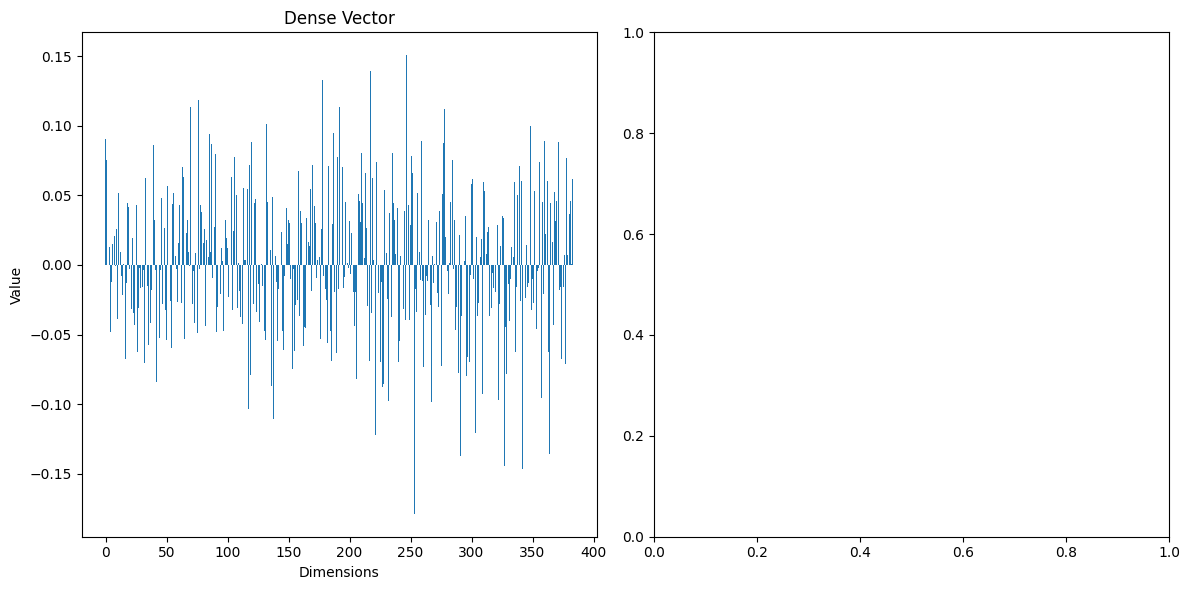

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [22]:
# Dense vs Sparse Vector Comparison to see the visualization
import matplotlib.pyplot as plt

dense_vector = model.encode("The cat is on the roof.")
sparse_vector = sparse_embeddings.toarray()[0]  

# create side by side bar chart to compare the values of dense and sparse vector
fig , axis = plt.subplots(1, 2, figsize=(12, 6))

# left chart for dense vector
axis[0].bar(range(len(dense_vector)), dense_vector)
axis[0].set_title("Dense Vector")
axis[0].set_xlabel("Dimensions")
axis[0].set_ylabel("Value")
plt.tight_layout()
plt.show()

# right chart for sparse vector
axis[1].bar(range(len(sparse_vector)), sparse_vector)
axis[1].set_title("Sparse Vector")
axis[1].set_xlabel("Dimensions")
axis[1].set_ylabel("Value")
plt.tight_layout()
plt.show()


plt.suptitle("Dense vs Sparse Vector Comparison", fontsize=16 , y=1.05)
plt.show()
